# SARSA for a 5×5 Grid Maze
### Student notebook version

This notebook is designed to go **with your video**.  
After watching the animation, you can come here and run the algorithm **one step at a time**.

You will be able to:
- start an episode from the top-left corner
- take one **SARSA** update at a time
- inspect the exact transition `(s, a, r, s', a')`
- see how one Q-value changes after each step
- watch the greedy arrows slowly become a policy
- run the same training schedule as the video
- finish with a greedy demo run

This notebook follows the SARSA Manim scene you uploaded, including the same environment, seed, and training schedule.

## Environment summary

This notebook follows the same environment as the video:

- **Grid:** 5 × 5
- **Start:** top-left `(0,0)`
- **Goal:** bottom-right `(4,4)`, reward `+1.0`, **terminal**
- **Trap:** reward `-1.0`, but **not terminal**
- **Mud:** reward `-0.5`
- **Normal step:** reward `-0.04`
- **Wall hit:** reward `-0.1`, and the agent stays in place

### SARSA update rule

\[
Q(s,a)\leftarrow Q(s,a) + lpha \Big[r + \gamma Q(s',a') - Q(s,a)\Big]
\]

The important idea is:

- **Q-learning** uses `max_a' Q(s',a')`
- **SARSA** uses the **actually chosen** next action `a'`

That is why SARSA is called **on-policy**.

### Training schedule from the video

- **Episodes 1–5:** visual training, `max_steps = 30`, `epsilon` starts at `0.30` and decays by `×0.85`
- **Episodes 6–24:** fast backend training, `max_steps = 50`, `epsilon = 0.05`
- **Episode 25:** final greedy demo, `max_steps = 12`, no learning update

In [ ]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from matplotlib.patches import Rectangle, FancyArrowPatch

class SARSAExplorer:
    """
    Student-facing explorer for the SARSA video.

    Design choices copied from the Manim demo:
    - 5x5 grid
    - alpha = 0.5
    - gamma = 0.9
    - epsilon starts at 0.30
    - Goal (+1.0) is terminal
    - Trap (-1.0) is NOT terminal; it is a normal transition with a big negative reward
    - Mud = -0.5
    - Normal step = -0.04
    - Wall hit = -0.1 and the agent stays in place
    - Episodes 1-5: visual / slow, max 30 steps, epsilon decays by x0.85 each episode
    - Episodes 6-24: backend / fast, max 50 steps, epsilon fixed at 0.05
    - Episode 25: final greedy demo, max 12 steps, no learning update
    """

    ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    ACTION_NAMES = ["UP", "DOWN", "LEFT", "RIGHT"]
    ACTION_ARROWS = {0: "↑", 1: "↓", 2: "←", 3: "→"}
    ACTION_TO_DELTA = {
        0: (0.00, -0.28),
        1: (0.00,  0.28),
        2: (-0.28, 0.00),
        3: (0.28,  0.00),
    }
    CELL_COLORS = {
        "goal": "#147d75",
        "trap": "#8c1d1d",
        "mud":  "#f06a00",
        "step": "#3d4a5f",
    }

    def __init__(self, alpha=0.5, gamma=0.9, epsilon=0.3, seed=42):
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.epsilon0 = float(epsilon)
        self.seed = int(seed)

        self.grid_size = 5
        self.start_state = (0, 0)
        self.goal_state = (4, 4)
        self.optimal_steps = 8

        self.rewards = np.array([
            [-0.04, -0.04, -0.04, -0.50, -1.00],
            [-0.04, -1.00, -0.04, -1.00, -1.00],
            [-0.04, -0.50, -0.04, -0.04, -0.04],
            [-1.00, -1.00, -1.00, -1.00, -0.04],
            [-1.00, -0.04, -0.04, -0.04,  1.00],
        ], dtype=float)

        self.reset(seed=seed)

    # ----------------------------
    # Core state management
    # ----------------------------
    def reset(self, seed=None):
        if seed is not None:
            self.seed = int(seed)

        self.rng = np.random.default_rng(self.seed)
        random.seed(self.seed)

        self.q_table = np.zeros((self.grid_size, self.grid_size, 4), dtype=float)

        # In the video, initial displayed arrows point RIGHT.
        self.arrow_directions = {
            (r, c): 3
            for r in range(self.grid_size)
            for c in range(self.grid_size)
            if (r, c) != self.goal_state
        }

        self.steps_hist = []
        self.returns_hist = []
        self.episode_summaries = []
        self.step_logs = []

        self.current_episode = 0
        self.current_step = 0
        self.current_return = 0.0
        self.current_state = self.start_state
        self.current_path = [self.start_state]
        self.current_epsilon = self.epsilon0
        self.in_episode = False
        self.final_demo = False
        self.done = False
        self.max_steps_current = None
        self.last_step_info = None

        # SARSA-specific state: the current chosen action A
        self.current_action = None
        self.current_action_is_exploring = None
        self.current_greedy_action = None

        print(f"Reset complete. Seed = {self.seed}. Q-table is all zeros.")

    def state_label(self, state):
        return f"(r{state[0]}, c{state[1]})"

    def moving_avg(self, values, window=5):
        if not values:
            return []
        out = []
        for i in range(len(values)):
            start = max(0, i - window + 1)
            out.append(float(np.mean(values[start:i + 1])))
        return out

    def cell_kind(self, r, c):
        reward = self.rewards[r, c]
        if (r, c) == self.goal_state:
            return "goal"
        if np.isclose(reward, -1.0):
            return "trap"
        if np.isclose(reward, -0.5):
            return "mud"
        return "step"

    def greedy_for_display(self, qvals, prefer_action_idx=None):
        max_val = float(np.max(qvals))
        best = np.flatnonzero(np.isclose(qvals, max_val))
        if len(best) == 1:
            return int(best[0])
        if prefer_action_idx is not None and prefer_action_idx in best:
            return int(prefer_action_idx)
        return int(self.rng.choice(best))

    def best_action_det(self, r, c):
        q = self.q_table[r, c]
        max_val = np.max(q)
        best = np.flatnonzero(np.isclose(q, max_val))
        saved_act = self.arrow_directions.get((r, c), None)
        if saved_act is not None and saved_act in best:
            return int(saved_act)
        return int(self.rng.choice(best))

    def epsilon_greedy(self, state, epsilon=None, greedy_only=False):
        r, c = state
        greedy_idx = self.best_action_det(r, c)

        if greedy_only:
            return greedy_idx, False, greedy_idx

        if epsilon is None:
            epsilon = self.current_epsilon

        if self.rng.random() < float(epsilon):
            return int(self.rng.integers(4)), True, greedy_idx
        return int(greedy_idx), False, greedy_idx

    def refresh_policy_from_q(self):
        """
        Recompute the displayed greedy arrow in every non-goal cell.
        """
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) == self.goal_state:
                    continue
                saved = self.arrow_directions.get((r, c), 3)
                self.arrow_directions[(r, c)] = self.greedy_for_display(
                    self.q_table[r, c],
                    prefer_action_idx=saved
                )

    # ----------------------------
    # Environment dynamics
    # ----------------------------
    def get_step_result(self, curr_pos, action_idx):
        r, c = curr_pos
        di, dj = self.ACTIONS[action_idx]
        next_r, next_c = r + di, c + dj
        hit_wall = False

        if 0 <= next_r < self.grid_size and 0 <= next_c < self.grid_size:
            reward = float(self.rewards[next_r, next_c])
            next_pos = (next_r, next_c)
        else:
            reward = -0.1
            next_pos = curr_pos
            hit_wall = True

        return next_pos, reward, hit_wall

    # ----------------------------
    # Episode control
    # ----------------------------
    def begin_episode(self, episode=None, max_steps=30, epsilon=None, final_demo=False):
        if episode is None:
            episode = self.current_episode + 1

        self.current_episode = int(episode)
        self.current_step = 0
        self.current_return = 0.0
        self.current_state = self.start_state
        self.current_path = [self.start_state]
        self.in_episode = True
        self.final_demo = bool(final_demo)
        self.done = False
        self.max_steps_current = int(max_steps)

        if epsilon is not None:
            self.current_epsilon = float(epsilon)
        elif final_demo:
            self.current_epsilon = 0.0

        self.last_step_info = None

        # SARSA picks an initial action A from the start state
        a0, exploring0, greedy0 = self.epsilon_greedy(
            self.current_state,
            epsilon=self.current_epsilon,
            greedy_only=self.final_demo
        )
        self.current_action = int(a0)
        self.current_action_is_exploring = bool(exploring0)
        self.current_greedy_action = int(greedy0)

        print(
            f"Started episode {self.current_episode} | "
            f"epsilon = {self.current_epsilon:.3f} | "
            f"max_steps = {self.max_steps_current} | "
            f"final_demo = {self.final_demo}"
        )
        print(
            f"Initial SARSA action A at {self.state_label(self.current_state)}: "
            f"{self.ACTION_NAMES[self.current_action]} "
            f"({'explore' if self.current_action_is_exploring else 'exploit'})"
        )

    def step_episode(self, verbose=True):
        if not self.in_episode or self.done:
            raise RuntimeError("Start an episode first with begin_episode(...).")

        r, c = self.current_state
        action_idx = int(self.current_action)
        is_exploring = bool(self.current_action_is_exploring)
        greedy_idx = int(self.current_greedy_action)

        next_pos, reward, hit_wall = self.get_step_result(self.current_state, action_idx)

        reached_goal = (next_pos == self.goal_state and next_pos != self.current_state)
        terminal = reached_goal

        # Choose A' from S' using the SAME epsilon-greedy policy
        if terminal:
            next_action_idx = None
            next_is_exploring = False
            next_greedy_idx = None
            q_next = 0.0
        else:
            next_action_idx, next_is_exploring, next_greedy_idx = self.epsilon_greedy(
                next_pos,
                epsilon=self.current_epsilon,
                greedy_only=self.final_demo
            )
            q_next = float(self.q_table[next_pos[0], next_pos[1], next_action_idx])

        old_q = float(self.q_table[r, c, action_idx])
        target = reward + self.gamma * q_next
        td_error = target - old_q

        if self.final_demo:
            new_q = old_q
        else:
            new_q = old_q + self.alpha * td_error
            self.q_table[r, c, action_idx] = new_q

            # Update displayed greedy arrow in the current state
            qvals = self.q_table[r, c]
            best_act_idx = self.greedy_for_display(qvals, prefer_action_idx=action_idx)
            self.arrow_directions[(r, c)] = best_act_idx

        self.current_state = next_pos
        self.current_step += 1
        self.current_return += float(reward)
        self.current_path.append(next_pos)

        # Advance SARSA pointer: A <- A'
        self.current_action = next_action_idx
        self.current_action_is_exploring = next_is_exploring
        self.current_greedy_action = next_greedy_idx

        self.done = reached_goal or (self.current_step >= self.max_steps_current)

        termination_reason = None
        if reached_goal:
            termination_reason = "goal"
        elif self.current_step >= self.max_steps_current:
            termination_reason = "max_steps"

        info = {
            "episode": self.current_episode,
            "step": self.current_step,
            "state": (r, c),
            "action_idx": action_idx,
            "action": self.ACTION_NAMES[action_idx],
            "decision": "explore" if is_exploring else "exploit",
            "greedy_action": self.ACTION_NAMES[greedy_idx],
            "next_state": next_pos,
            "reward": round(float(reward), 3),
            "hit_wall": hit_wall,
            "reached_goal": reached_goal,
            "next_action_idx": next_action_idx,
            "next_action": None if next_action_idx is None else self.ACTION_NAMES[next_action_idx],
            "next_decision": (
                "terminal" if next_action_idx is None
                else ("explore" if next_is_exploring else "exploit")
            ),
            "q_next": round(float(q_next), 4),
            "old_q": round(float(old_q), 4),
            "target": round(float(target), 4),
            "td_error": round(float(td_error), 4),
            "new_q": round(float(new_q), 4),
            "episode_return_so_far": round(float(self.current_return), 4),
            "done": self.done,
            "termination_reason": termination_reason,
        }

        self.last_step_info = info
        self.step_logs.append(info)

        if verbose:
            print(
                f"Ep {self.current_episode} | step {self.current_step}: "
                f"{self.state_label((r, c))} --{self.ACTION_NAMES[action_idx]}--> "
                f"{self.state_label(next_pos)} | reward = {reward:+.2f} | "
                f"{info['decision']}"
            )

            if not self.final_demo:
                if next_action_idx is None:
                    print(
                        f"SARSA update: old = {old_q:.4f}, target = {target:.4f} "
                        f"(terminal), td_error = {td_error:.4f}, new = {new_q:.4f}"
                    )
                else:
                    print(
                        f"SARSA update uses Q(s',a') with a' = {self.ACTION_NAMES[next_action_idx]} "
                        f"({info['next_decision']})."
                    )
                    print(
                        f"old = {old_q:.4f}, q_next = {q_next:.4f}, "
                        f"target = {target:.4f}, td_error = {td_error:.4f}, new = {new_q:.4f}"
                    )

            if hit_wall:
                print("Hit a wall, so the agent stayed in the same cell.")

            if reached_goal:
                print("Reached the goal. Episode finished.")
            elif self.done:
                print("Reached the step limit for this episode.")

        if self.done:
            self.finish_episode()

        return info

    def finish_episode(self):
        if not self.in_episode:
            return

        if not self.final_demo:
            self.steps_hist.append(self.current_step)
            self.returns_hist.append(self.current_return)
            self.episode_summaries.append({
                "episode": self.current_episode,
                "steps": self.current_step,
                "return": round(float(self.current_return), 4),
                "epsilon": round(float(self.current_epsilon), 4),
            })

        self.in_episode = False

    def step_and_render(self, title=None, figsize=(14, 6)):
        info = self.step_episode(verbose=True)
        if title is None:
            title = f"SARSA | Episode {self.current_episode} | after step {self.current_step}"
        self.render(title=title, figsize=figsize)
        return info

    def run_episode(self, max_steps=None, epsilon=None, final_demo=False, render_each=False):
        if max_steps is None:
            max_steps = self.max_steps_current or (12 if final_demo else 30)

        if not self.in_episode or self.done:
            self.begin_episode(
                episode=self.current_episode + 1,
                max_steps=max_steps,
                epsilon=epsilon,
                final_demo=final_demo,
            )

        logs = []
        while self.in_episode and not self.done:
            info = self.step_episode(verbose=False)
            logs.append(info)
            if render_each:
                self.render(title=f"Episode {self.current_episode} after step {self.current_step}")

        if logs:
            print(
                f"Episode {self.current_episode} finished in "
                f"{self.current_step} step(s) with return {self.current_return:.2f}."
            )
        else:
            print("No step was run.")

        return pd.DataFrame(logs)

    # ----------------------------
    # Video schedule helpers
    # ----------------------------
    def run_visual_schedule(self):
        rows = []
        eps = self.epsilon0

        for ep in range(1, 6):
            self.begin_episode(episode=ep, max_steps=30, epsilon=eps, final_demo=False)
            self.run_episode(max_steps=30, epsilon=eps, final_demo=False, render_each=False)

            rows.append({
                "episode": ep,
                "steps": self.current_step,
                "return": round(float(self.current_return), 4),
                "epsilon_used": round(float(eps), 4),
            })

            eps = max(0.05, eps * 0.85)
            self.current_epsilon = eps

        return pd.DataFrame(rows)

    def run_backend_schedule(self):
        self.current_epsilon = 0.05
        rows = []

        for ep in range(6, 25):
            self.begin_episode(episode=ep, max_steps=50, epsilon=0.05, final_demo=False)
            self.run_episode(max_steps=50, epsilon=0.05, final_demo=False, render_each=False)
            rows.append({
                "episode": ep,
                "steps": self.current_step,
                "return": round(float(self.current_return), 4),
            })

        self.refresh_policy_from_q()
        return pd.DataFrame(rows)

    def run_final_demo(self, max_steps=12):
        self.begin_episode(episode=25, max_steps=max_steps, epsilon=0.0, final_demo=True)
        logs = []

        while self.in_episode and not self.done:
            logs.append(self.step_episode(verbose=False))

        if logs:
            print(
                f"Final greedy demo ended after {self.current_step} step(s). "
                f"Termination: {self.last_step_info['termination_reason']}."
            )

        return pd.DataFrame(logs)

    # ----------------------------
    # Tables for learning
    # ----------------------------
    def values_table(self):
        arr = np.max(self.q_table, axis=2)
        idx = [f"r{r}" for r in range(self.grid_size)]
        cols = [f"c{c}" for c in range(self.grid_size)]
        return pd.DataFrame(np.round(arr, 3), index=idx, columns=cols)

    def policy_table(self):
        data = []
        for r in range(self.grid_size):
            row = []
            for c in range(self.grid_size):
                if (r, c) == self.goal_state:
                    row.append("GOAL")
                else:
                    act = self.arrow_directions.get(
                        (r, c),
                        self.greedy_for_display(self.q_table[r, c], prefer_action_idx=3)
                    )
                    row.append(self.ACTION_ARROWS[act])
            data.append(row)

        return pd.DataFrame(
            data,
            index=[f"r{r}" for r in range(self.grid_size)],
            columns=[f"c{c}" for c in range(self.grid_size)],
        )

    def q_table_for_state(self, state):
        r, c = state
        rows = []

        for a_idx in range(4):
            next_state, reward, hit_wall = self.get_step_result(state, a_idx)
            rows.append({
                "action": self.ACTION_NAMES[a_idx],
                "arrow": self.ACTION_ARROWS[a_idx],
                "q_value": round(float(self.q_table[r, c, a_idx]), 4),
                "next_state": next_state,
                "reward": reward,
                "hit_wall": hit_wall,
            })

        df = pd.DataFrame(rows)
        return df.sort_values("q_value", ascending=False, kind="stable").reset_index(drop=True)

    def possible_targets(self, state, action_idx):
        """
        Educational helper:
        If we take action a in state s, what SARSA targets are possible
        depending on which next action a' is chosen in s'?
        """
        next_state, reward, hit_wall = self.get_step_result(state, action_idx)

        if next_state == self.goal_state and next_state != state:
            return pd.DataFrame([{
                "state": state,
                "action": self.ACTION_NAMES[action_idx],
                "next_state": next_state,
                "reward": reward,
                "candidate_next_action": "TERMINAL",
                "q_next": 0.0,
                "target": round(float(reward), 4),
                "is_greedy_next": True,
                "hit_wall": hit_wall,
            }])

        rows = []
        next_q = self.q_table[next_state[0], next_state[1]]
        max_q = float(np.max(next_q))

        for a_next in range(4):
            qn = float(next_q[a_next])
            rows.append({
                "state": state,
                "action": self.ACTION_NAMES[action_idx],
                "next_state": next_state,
                "reward": reward,
                "candidate_next_action": self.ACTION_NAMES[a_next],
                "q_next": round(qn, 4),
                "target": round(float(reward + self.gamma * qn), 4),
                "is_greedy_next": bool(np.isclose(qn, max_q)),
                "hit_wall": hit_wall,
            })

        return pd.DataFrame(rows)

    def inspect_state(self, state):
        df = self.q_table_for_state(state)
        best = df.iloc[0]

        print(f"State {self.state_label(state)}")
        print(
            f"Greedy action right now: {best['action']} {best['arrow']} "
            f"with Q = {best['q_value']:.4f}"
        )
        print("Remember: SARSA does not use max_a' Q(s',a') in the update.")
        print("It uses the Q-value of the actually chosen next action a'.")
        return df

    def episode_summary_table(self):
        if not self.episode_summaries:
            return pd.DataFrame(columns=["episode", "steps", "return", "epsilon"])
        return pd.DataFrame(self.episode_summaries)

    def recent_step_log(self, n=10):
        if not self.step_logs:
            return pd.DataFrame()
        return pd.DataFrame(self.step_logs[-n:])

    def show_status(self):
        status = {
            "episode": self.current_episode,
            "step_in_episode": self.current_step,
            "current_state": self.current_state,
            "current_action": None if self.current_action is None else self.ACTION_NAMES[self.current_action],
            "current_action_mode": None if self.current_action is None else (
                "explore" if self.current_action_is_exploring else "exploit"
            ),
            "epsilon": round(float(self.current_epsilon), 4),
            "episode_return": round(float(self.current_return), 4),
            "in_episode": self.in_episode,
            "done": self.done,
            "final_demo": self.final_demo,
        }
        return pd.DataFrame([status])

    # ----------------------------
    # Plotting
    # ----------------------------
    def render(self, title="SARSA Explorer", figsize=(14, 6), show_path=True):
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(
            2, 2,
            width_ratios=[1.18, 0.82],
            height_ratios=[1, 1],
            wspace=0.28,
            hspace=0.32
        )

        ax_grid = fig.add_subplot(gs[:, 0])
        ax_steps = fig.add_subplot(gs[0, 1])
        ax_ret = fig.add_subplot(gs[1, 1])

        # ----- Grid -----
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                kind = self.cell_kind(r, c)
                rect = Rectangle(
                    (c, r), 1, 1,
                    facecolor=self.CELL_COLORS[kind],
                    edgecolor="white",
                    linewidth=2.5,
                )
                ax_grid.add_patch(rect)

                reward = self.rewards[r, c]
                if kind == "goal":
                    reward_text = "Goal\n+1.0"
                    reward_color = "yellow"
                elif kind == "trap":
                    reward_text = "Trap\n-1.0"
                    reward_color = "white"
                elif kind == "mud":
                    reward_text = "Mud\n-0.5"
                    reward_color = "white"
                else:
                    reward_text = "-0.04"
                    reward_color = "white"

                ax_grid.text(
                    c + 0.5, r + 0.22, reward_text,
                    ha="center", va="center",
                    fontsize=13, color=reward_color,
                )

                max_q = float(np.max(self.q_table[r, c]))
                val_color = "#6ef58b" if max_q > 0.01 else ("#ff8a8a" if max_q < -0.01 else "white")
                ax_grid.text(
                    c + 0.5, r + 0.69, f"{max_q:.3f}",
                    ha="center", va="center",
                    fontsize=18, color=val_color,
                )

                if (r, c) != self.goal_state:
                    act = self.arrow_directions.get((r, c), 3)
                    dx, dy = self.ACTION_TO_DELTA[act]
                    start = (c + 0.5, r + 0.50)
                    end = (c + 0.5 + dx, r + 0.50 + dy)
                    arr = FancyArrowPatch(
                        start, end,
                        arrowstyle="-|>",
                        mutation_scale=18,
                        lw=2.4,
                        color="gold",
                    )
                    ax_grid.add_patch(arr)

        # Start marker
        ax_grid.scatter(
            [self.start_state[1] + 0.15],
            [self.start_state[0] + 0.85],
            s=120,
            color="deepskyblue",
            label="Start",
            zorder=6
        )

        # Current path
        if show_path and len(self.current_path) > 1:
            xs = [c + 0.5 for (_, c) in self.current_path]
            ys = [r + 0.5 for (r, _) in self.current_path]
            path_color = "limegreen" if self.final_demo else "skyblue"
            ax_grid.plot(xs, ys, color=path_color, linewidth=2.5, alpha=0.9, zorder=4)

        # Current marker
        show_current = not (self.current_state == self.start_state and self.current_step == 0)
        if show_current:
            ax_grid.scatter(
                [self.current_state[1] + 0.5],
                [self.current_state[0] + 0.5],
                s=140,
                color=("limegreen" if self.final_demo else "royalblue"),
                edgecolor="white",
                linewidth=1.5,
                label="Current",
                zorder=7
            )

        # End marker if episode finished
        if self.done and self.current_path:
            end_r, end_c = self.current_path[-1]
            offset_x = 0.0
            offset_y = 0.0
            if (end_r, end_c) == self.start_state:
                offset_x = 0.18
                offset_y = -0.18
            ax_grid.scatter(
                [end_c + 0.5 + offset_x],
                [end_r + 0.5 + offset_y],
                s=110,
                color="orange",
                label="End",
                zorder=8
            )

        ax_grid.set_xlim(0, self.grid_size)
        ax_grid.set_ylim(self.grid_size, 0)
        ax_grid.set_xticks(np.arange(0.5, self.grid_size + 0.5, 1), labels=[f"c{c}" for c in range(self.grid_size)])
        ax_grid.set_yticks(np.arange(0.5, self.grid_size + 0.5, 1), labels=[f"r{r}" for r in range(self.grid_size)])
        ax_grid.set_title(title, fontsize=18)
        ax_grid.set_aspect("equal")
        ax_grid.legend(loc="upper left")

        # ----- Steps chart -----
        steps_ma = self.moving_avg(self.steps_hist, window=5)
        if self.steps_hist:
            ax_steps.plot(
                range(1, len(steps_ma) + 1),
                steps_ma,
                marker="o"
            )
        ax_steps.axhline(self.optimal_steps, linestyle="--")
        ax_steps.set_title("Moving Average of Steps")
        ax_steps.set_xlabel("Episode")
        ax_steps.set_ylabel("Steps")
        ax_steps.set_xlim(1, 24)
        ax_steps.set_ylim(0, 30)

        # ----- Return chart -----
        ret_ma = self.moving_avg(self.returns_hist, window=5)
        if self.returns_hist:
            ax_ret.plot(
                range(1, len(ret_ma) + 1),
                ret_ma,
                marker="o"
            )
        ax_ret.set_title("Moving Average of Return")
        ax_ret.set_xlabel("Episode")
        ax_ret.set_ylabel("Return")
        ax_ret.set_xlim(1, 24)
        ax_ret.set_ylim(-12, 2)

        # ----- Status box -----
        if self.last_step_info is None:
            action_text = "None"
            mode_text = "N/A"
            if self.current_action is not None:
                action_text = self.ACTION_NAMES[self.current_action]
                mode_text = "explore" if self.current_action_is_exploring else "exploit"

            status_lines = [
                f"Episode: {self.current_episode}",
                f"Current state: {self.state_label(self.current_state)}",
                f"Epsilon: {self.current_epsilon:.3f}",
                f"Step in episode: {self.current_step}",
                f"Episode return: {self.current_return:.2f}",
                f"Chosen action A: {action_text} ({mode_text})",
                "No transition has been taken yet."
            ]
        else:
            info = self.last_step_info
            next_line = "terminal"
            if info["next_action"] is not None:
                next_line = f"{info['next_action']} ({info['next_decision']})"

            status_lines = [
                f"Episode: {self.current_episode}",
                f"Current state: {self.state_label(self.current_state)}",
                f"Epsilon: {self.current_epsilon:.3f}",
                f"Used action A: {info['action']} ({info['decision']})",
                f"Chosen next action A': {next_line}",
                f"Reward: {info['reward']:+.2f}",
                f"Q old → new: {info['old_q']:.3f} → {info['new_q']:.3f}",
            ]
            if info["done"]:
                status_lines.append(f"Episode finished: {info['termination_reason']}")

        ax_steps.text(
            0.02, 0.97,
            "\n".join(status_lines),
            transform=ax_steps.transAxes,
            ha="left", va="top",
            fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.87)
        )

        plt.show()

## 1. Create a fresh demo object

If the notebook ever feels messy, rerun this cell to go back to a clean state.

In [3]:
demo = SARSAExplorer(alpha=0.5, gamma=0.9, epsilon=0.3, seed=42)

Reset complete. Seed = 42. Q-table is all zeros.


## 2. Look at the initial grid

At the beginning:
- all Q-values are `0`
- every displayed arrow points **right**
- the agent has not moved yet
- no episode has started yet

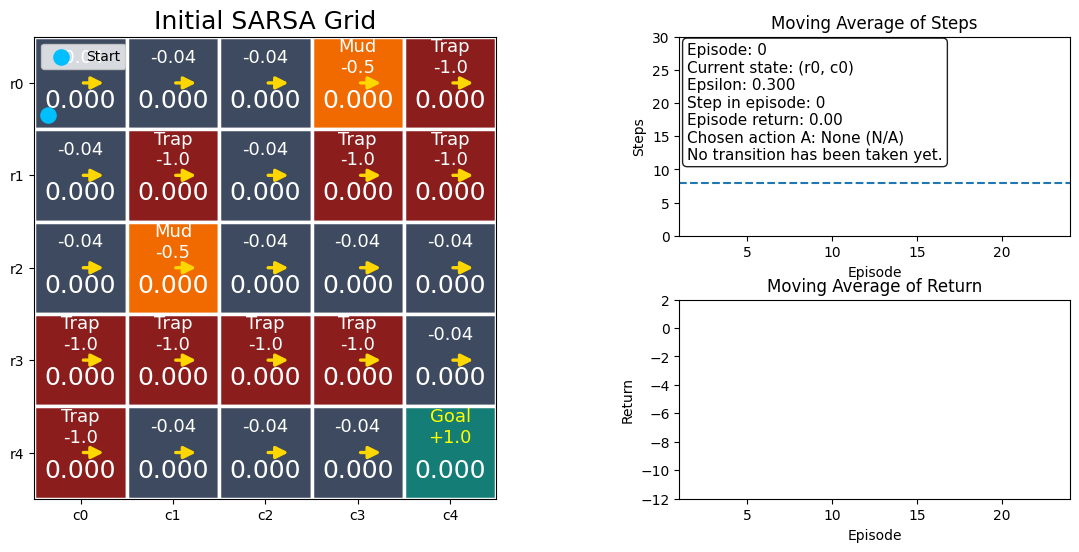

In [10]:
demo.render(title="Initial SARSA Grid")

## 3. Inspect one state before learning starts

Here we look at state `(0,0)` before any learning happens.

Notice:
- all four Q-values are tied at `0`
- the displayed arrow is only a **visual tie-break**
- SARSA still needs an actual chosen action `A` when the episode begins

In [12]:
demo.inspect_state((0, 0))

State (r0, c0)
Greedy action right now: UP ↑ with Q = 0.0000
Remember: SARSA does not use max_a' Q(s',a') in the update.
It uses the Q-value of the actually chosen next action a'.


,action,arrow,q_value,next_state,reward,hit_wall
0,UP,↑,0.0,"(0, 0)",-0.10,True
1,DOWN,↓,0.0,"(1, 0)",-0.04,False
2,LEFT,←,0.0,"(0, 0)",-0.10,True
3,RIGHT,→,0.0,"(0, 1)",-0.04,False


## 4. Start Episode 1

This matches the beginning of the video:
- episode = 1
- epsilon = 0.30
- max_steps = 30

Unlike Q-learning, SARSA also picks an **initial action `A`** right away.

Started episode 1 | epsilon = 0.300 | max_steps = 30 | final_demo = False
Initial SARSA action A at (r0, c0): RIGHT (exploit)


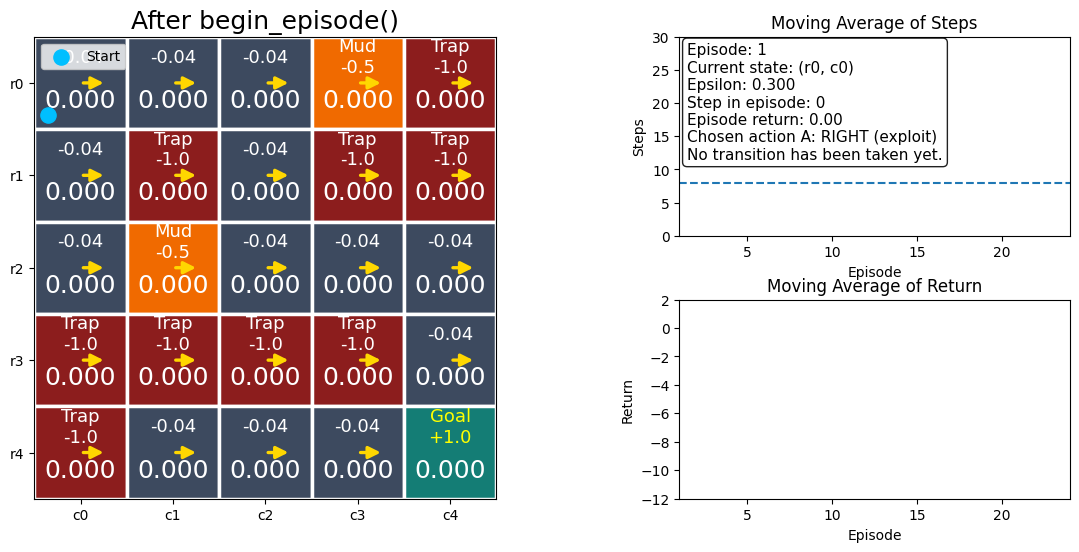

In [24]:
demo.begin_episode(episode=1, max_steps=30, epsilon=0.30, final_demo=False)
demo.render(title="After begin_episode()")

## 5. Take exactly one SARSA step

This is the most important cell in the notebook.

A single SARSA update uses:

- current state `s`
- current chosen action `a`
- observed reward `r`
- next state `s'`
- next chosen action `a'`

Run this cell repeatedly to follow the learning process **step by step**.

Ep 1 | step 12: (r2, c4) --RIGHT--> (r2, c4) | reward = -0.10 | exploit
SARSA update uses Q(s',a') with a' = DOWN (exploit).
old = -0.0500, q_next = 0.0000, target = -0.1000, td_error = -0.0500, new = -0.0750
Hit a wall, so the agent stayed in the same cell.


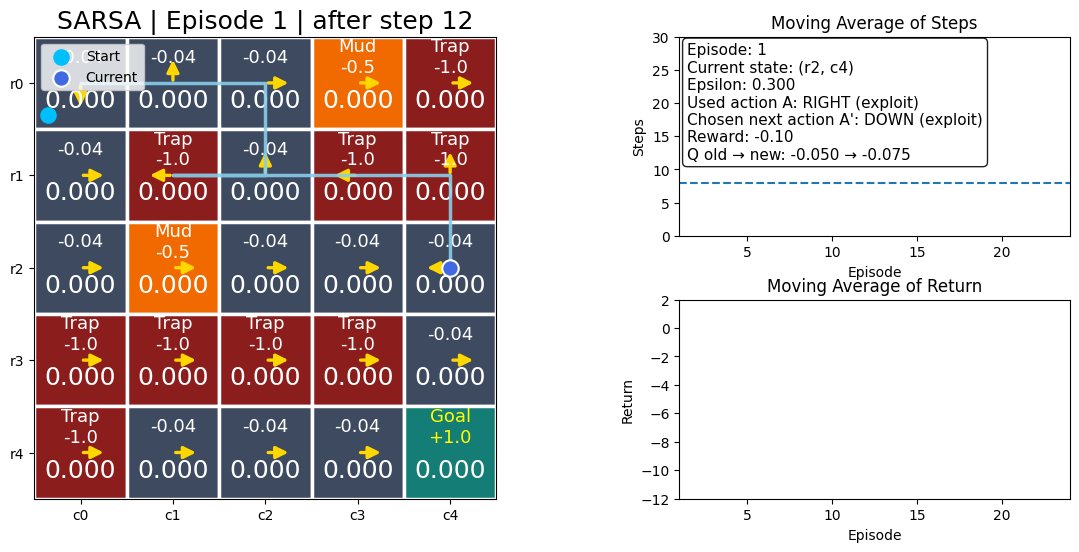

{'episode': 1,
 'step': 12,
 'state': (2, 4),
 'action_idx': 3,
 'action': 'RIGHT',
 'decision': 'exploit',
 'greedy_action': 'RIGHT',
 'next_state': (2, 4),
 'reward': -0.1,
 'hit_wall': True,
 'reached_goal': False,
 'next_action_idx': 1,
 'next_action': 'DOWN',
 'next_decision': 'exploit',
 'q_next': 0.0,
 'old_q': -0.05,
 'target': -0.1,
 'td_error': -0.05,
 'new_q': -0.075,
 'episode_return_so_far': -3.6,
 'done': False,
 'termination_reason': None}

In [36]:
step_info = demo.step_and_render()
step_info

### Try this after a few steps

These helper views make the update easier to understand:
- current status
- max-Q value table
- greedy arrow table
- recent step log

In [38]:
demo.show_status()

,episode,step_in_episode,current_state,current_action,current_action_mode,epsilon,episode_return,in_episode,done,final_demo
0,1,12,"(2, 4)",DOWN,exploit,0.3,-3.6,True,False,False


In [39]:
demo.values_table()

,c0,c1,c2,c3,c4
r0,0.0,0.0,0.0,0.0,0.0
r1,0.0,0.0,0.0,0.0,0.0
r2,0.0,0.0,0.0,0.0,0.0
r3,0.0,0.0,0.0,0.0,0.0
r4,0.0,0.0,0.0,0.0,0.0


In [40]:
demo.policy_table()

,c0,c1,c2,c3,c4
r0,↓,↑,→,→,→
r1,→,←,↑,←,↑
r2,→,→,→,→,←
r3,→,→,→,→,→
r4,→,→,→,→,GOAL


In [41]:
demo.recent_step_log(5)

,episode,step,state,action_idx,action,decision,greedy_action,next_state,reward,hit_wall,...,next_action,next_decision,q_next,old_q,target,td_error,new_q,episode_return_so_far,done,termination_reason
0,1,8,"(1, 4)",3,RIGHT,exploit,RIGHT,"(1, 4)",-0.10,True,...,RIGHT,explore,0.0,0.00,-0.10,-0.10,-0.050,-3.26,False,None
1,1,9,"(1, 4)",3,RIGHT,explore,RIGHT,"(1, 4)",-0.10,True,...,DOWN,explore,0.0,-0.05,-0.10,-0.05,-0.075,-3.36,False,None
2,1,10,"(1, 4)",1,DOWN,explore,DOWN,"(2, 4)",-0.04,False,...,RIGHT,exploit,0.0,0.00,-0.04,-0.04,-0.020,-3.40,False,None
3,1,11,"(2, 4)",3,RIGHT,exploit,RIGHT,"(2, 4)",-0.10,True,...,RIGHT,exploit,0.0,0.00,-0.10,-0.10,-0.050,-3.50,False,None
4,1,12,"(2, 4)",3,RIGHT,exploit,RIGHT,"(2, 4)",-0.10,True,...,DOWN,exploit,0.0,-0.05,-0.10,-0.05,-0.075,-3.60,False,None


## 6. Finish the current episode automatically

After you manually inspect a few steps, run the rest of Episode 1 automatically.

In [42]:
ep1_log = demo.run_episode()
ep1_log.tail()

Episode 1 finished in 30 step(s) with return -10.90.


,episode,step,state,action_idx,action,decision,greedy_action,next_state,reward,hit_wall,...,next_action,next_decision,q_next,old_q,target,td_error,new_q,episode_return_so_far,done,termination_reason
13,1,26,"(0, 4)",0,UP,exploit,UP,"(0, 4)",-0.10,True,...,DOWN,exploit,0.0,-0.05,-0.10,-0.05,-0.075,-8.82,False,None
14,1,27,"(0, 4)",1,DOWN,exploit,DOWN,"(1, 4)",-1.00,False,...,LEFT,exploit,0.0,0.00,-1.00,-1.00,-0.500,-9.82,False,None
15,1,28,"(1, 4)",2,LEFT,exploit,LEFT,"(1, 3)",-1.00,False,...,LEFT,explore,0.0,0.00,-1.00,-1.00,-0.500,-10.82,False,None
16,1,29,"(1, 3)",2,LEFT,explore,LEFT,"(1, 2)",-0.04,False,...,DOWN,explore,0.0,0.00,-0.04,-0.04,-0.020,-10.86,False,None
17,1,30,"(1, 2)",1,DOWN,explore,UP,"(2, 2)",-0.04,False,...,RIGHT,exploit,0.0,0.00,-0.04,-0.04,-0.020,-10.90,True,max_steps


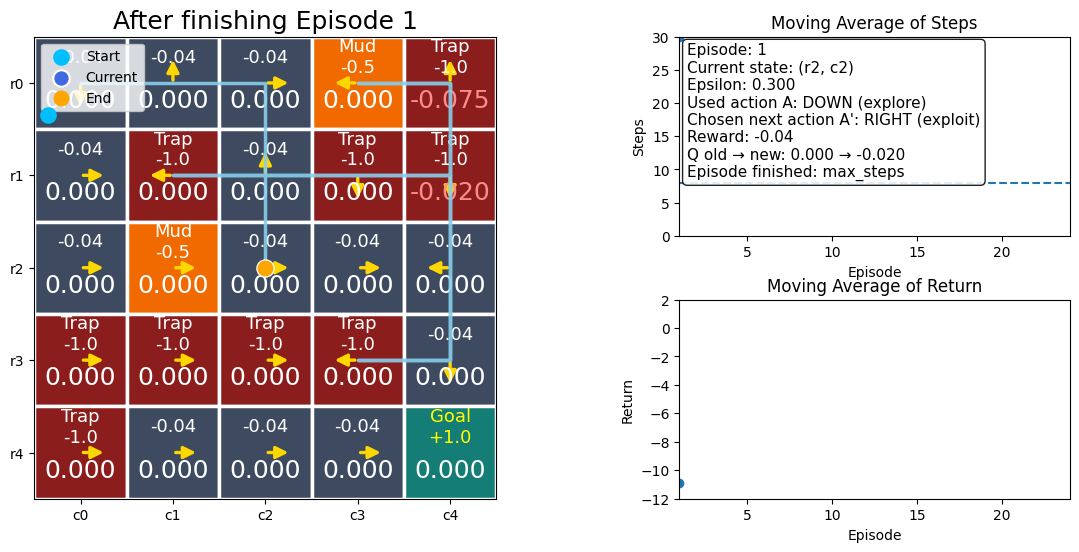

In [47]:
demo.render(title="After finishing Episode 1")

## 7. Inspect the updated Q-values of one state

You should now see that some actions are no longer tied.

In [50]:
demo.inspect_state((0, 0))

State (r0, c0)
Greedy action right now: UP ↑ with Q = 0.0000
Remember: SARSA does not use max_a' Q(s',a') in the update.
It uses the Q-value of the actually chosen next action a'.


,action,arrow,q_value,next_state,reward,hit_wall
0,UP,↑,0.00,"(0, 0)",-0.10,True
1,DOWN,↓,0.00,"(1, 0)",-0.04,False
2,LEFT,←,0.00,"(0, 0)",-0.10,True
3,RIGHT,→,-0.02,"(0, 1)",-0.04,False


## 8. Why SARSA is on-policy

For one fixed `(s,a)`, the target depends on which **next action `a'`** gets chosen in `s'`.

This helper shows all possible SARSA targets for the same transition, depending on `a'`.

In [51]:
demo.possible_targets((0, 0), 3)  # Try action RIGHT from the start state

,state,action,next_state,reward,candidate_next_action,q_next,target,is_greedy_next,hit_wall
0,"(0, 0)",RIGHT,"(0, 1)",-0.04,UP,0.00,-0.040,True,False
1,"(0, 0)",RIGHT,"(0, 1)",-0.04,DOWN,0.00,-0.040,True,False
2,"(0, 0)",RIGHT,"(0, 1)",-0.04,LEFT,0.00,-0.040,True,False
3,"(0, 0)",RIGHT,"(0, 1)",-0.04,RIGHT,-0.02,-0.058,False,False


## 9. Replay the full **visual part** of the video from scratch

This will simulate Episodes 1–5 with the same schedule as the animation:
- `epsilon` starts at `0.30`
- after each episode: `epsilon = max(0.05, epsilon × 0.85)`
- `max_steps = 30`

In [52]:
visual_demo = SARSAExplorer(alpha=0.5, gamma=0.9, epsilon=0.3, seed=42)
visual_summary = visual_demo.run_visual_schedule()
visual_summary

Reset complete. Seed = 42. Q-table is all zeros.
Started episode 1 | epsilon = 0.300 | max_steps = 30 | final_demo = False
Initial SARSA action A at (r0, c0): RIGHT (exploit)
Episode 1 finished in 30 step(s) with return -9.32.
Started episode 2 | epsilon = 0.255 | max_steps = 30 | final_demo = False
Initial SARSA action A at (r0, c0): DOWN (exploit)
Episode 2 finished in 30 step(s) with return -14.32.
Started episode 3 | epsilon = 0.217 | max_steps = 30 | final_demo = False
Initial SARSA action A at (r0, c0): LEFT (explore)
Episode 3 finished in 30 step(s) with return -11.24.
Started episode 4 | epsilon = 0.184 | max_steps = 30 | final_demo = False
Initial SARSA action A at (r0, c0): RIGHT (exploit)
Episode 4 finished in 30 step(s) with return -6.82.
Started episode 5 | epsilon = 0.157 | max_steps = 30 | final_demo = False
Initial SARSA action A at (r0, c0): UP (exploit)
Episode 5 finished in 30 step(s) with return -2.94.


,episode,steps,return,epsilon_used
0,1,30,-9.32,0.3000
1,2,30,-14.32,0.2550
2,3,30,-11.24,0.2167
3,4,30,-6.82,0.1842
4,5,30,-2.94,0.1566


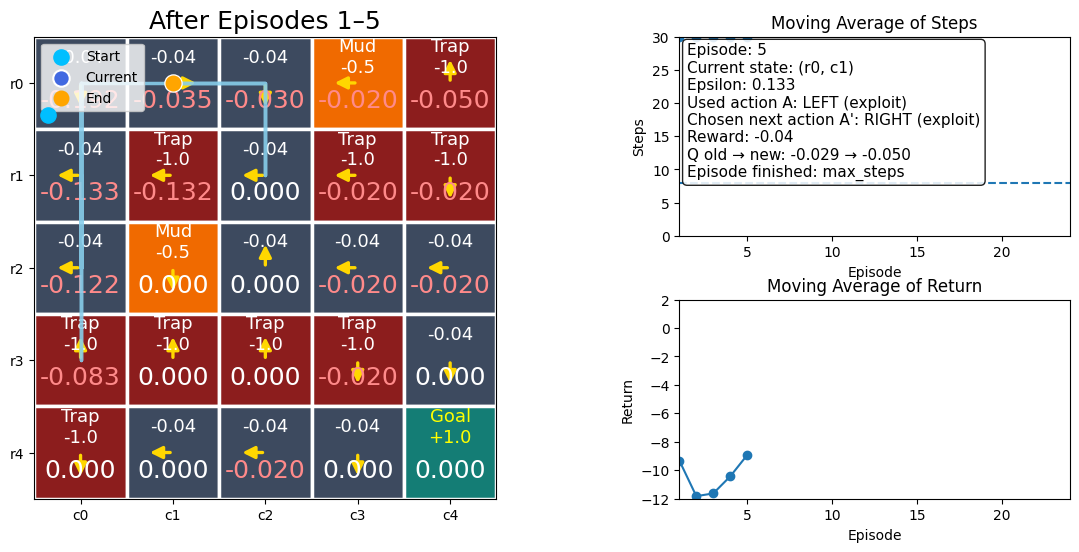

In [55]:
visual_demo.render(title="After Episodes 1–5")

## 10. Run the fast backend training (Episodes 6–24)

This follows the second part of the video:
- `epsilon = 0.05`
- `max_steps = 50`
- training runs without rendering every single step

In [56]:
backend_summary = visual_demo.run_backend_schedule()
backend_summary.head()

Started episode 6 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Initial SARSA action A at (r0, c0): DOWN (exploit)
Episode 6 finished in 35 step(s) with return -1.50.
Started episode 7 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Initial SARSA action A at (r0, c0): LEFT (explore)
Episode 7 finished in 17 step(s) with return 0.30.
Started episode 8 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Initial SARSA action A at (r0, c0): RIGHT (exploit)
Episode 8 finished in 21 step(s) with return 0.02.
Started episode 9 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Initial SARSA action A at (r0, c0): RIGHT (exploit)
Episode 9 finished in 50 step(s) with return -5.44.
Started episode 10 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Initial SARSA action A at (r0, c0): DOWN (exploit)
Episode 10 finished in 50 step(s) with return -2.54.
Started episode 11 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Initial SARSA action A at (r0, c0): DO

,episode,steps,return
0,6,35,-1.50
1,7,17,0.30
2,8,21,0.02
3,9,50,-5.44
4,10,50,-2.54


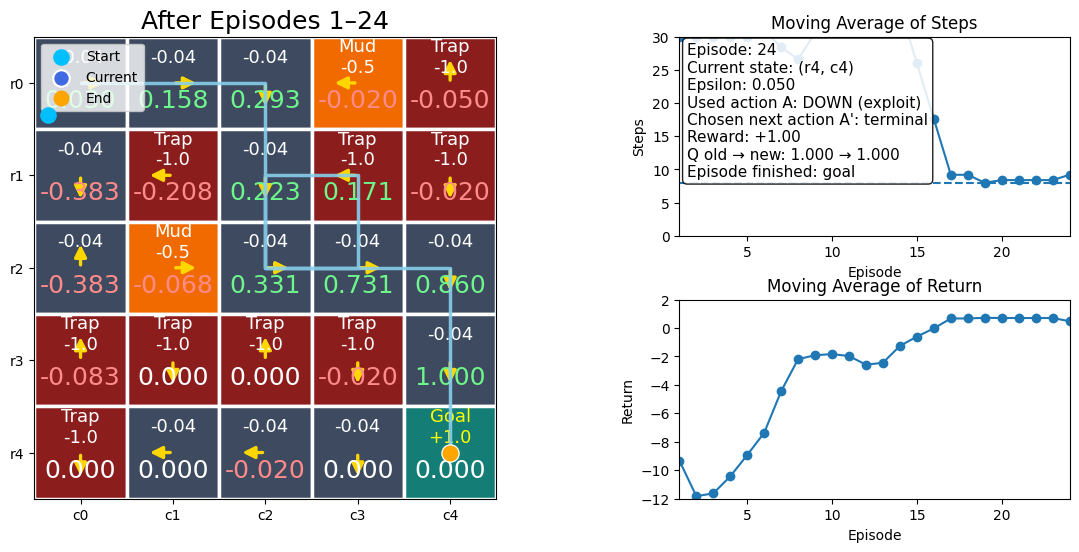

In [57]:
visual_demo.render(title="After Episodes 1–24")

## 11. Final greedy demo (Episode 25)

Now the agent uses a greedy policy only.
This is the notebook version of the green final run.

In [58]:
final_demo_log = visual_demo.run_final_demo(max_steps=12)
final_demo_log.tail()

Started episode 25 | epsilon = 0.000 | max_steps = 12 | final_demo = True
Initial SARSA action A at (r0, c0): RIGHT (exploit)
Final greedy demo ended after 8 step(s). Termination: goal.


,episode,step,state,action_idx,action,decision,greedy_action,next_state,reward,hit_wall,...,next_action,next_decision,q_next,old_q,target,td_error,new_q,episode_return_so_far,done,termination_reason
3,25,4,"(1, 2)",1,DOWN,exploit,DOWN,"(2, 2)",-0.04,False,...,RIGHT,exploit,0.3307,0.2235,0.2576,0.0341,0.2235,-0.16,False,None
4,25,5,"(2, 2)",3,RIGHT,exploit,RIGHT,"(2, 3)",-0.04,False,...,RIGHT,exploit,0.7310,0.3307,0.6179,0.2872,0.3307,-0.20,False,None
5,25,6,"(2, 3)",3,RIGHT,exploit,RIGHT,"(2, 4)",-0.04,False,...,DOWN,exploit,0.8596,0.7310,0.7336,0.0026,0.7310,-0.24,False,None
6,25,7,"(2, 4)",1,DOWN,exploit,DOWN,"(3, 4)",-0.04,False,...,DOWN,exploit,1.0000,0.8596,0.8600,0.0004,0.8596,-0.28,False,None
7,25,8,"(3, 4)",1,DOWN,exploit,DOWN,"(4, 4)",1.00,False,...,None,terminal,0.0000,1.0000,1.0000,0.0000,1.0000,0.72,True,goal


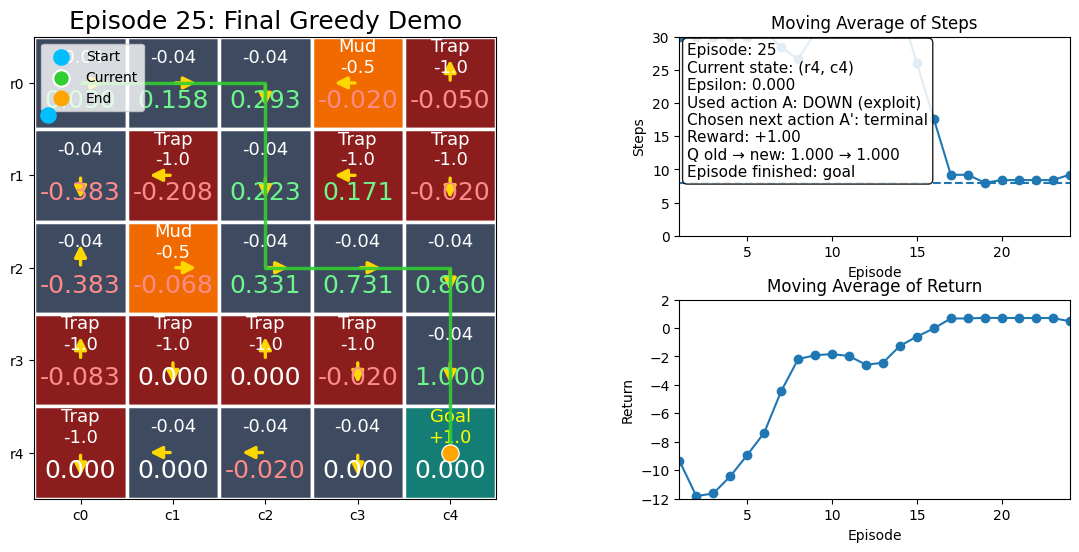

In [59]:
visual_demo.render(title="Episode 25: Final Greedy Demo")

## 12. Check the learned value view and policy view

In [ ]:
visual_demo.values_table()

In [ ]:
visual_demo.policy_table()

In [ ]:
visual_demo.episode_summary_table().tail(10)

## 13. Inspect a specific state in detail

Good states to inspect:
- `(0,0)` start area
- `(2,2)` center area
- `(3,4)` near the goal

In [ ]:
visual_demo.inspect_state((0, 0))
visual_demo.inspect_state((2, 2))

## 14. One-cell worksheet idea

Pick one state and one action.  
Then ask yourself:

1. Where does the agent go?
2. What reward does it get?
3. What next action `a'` might SARSA choose?
4. How would the target change if `a'` changes?

Try the cell below with different states and actions.

In [ ]:
state = (2, 2)
action_idx = 3  # 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
visual_demo.possible_targets(state, action_idx)

## 15. Reset and try your own experiment

For example:
- change `epsilon`
- change the random seed
- manually step through two or three episodes
- compare the learned policy with Q-learning

In [ ]:
my_demo = SARSAExplorer(alpha=0.5, gamma=0.9, epsilon=0.2, seed=42)
my_demo.render(title='My fresh SARSA experiment')